# 1. Importación de Librerías y Configuración del Entorno - Modelo Zero



In [3]:
# Librería para manejo de arreglos multidimensionales y operaciones matemáticas.
import numpy as np

# Librería para realizar peticiones HTTP (obtener datos de APIs o la web).
import requests

# Módulo para visualización de datos y generación de gráficos.
import matplotlib.pyplot as plt

# Clases para estructurar conjuntos de datos y cargarlos eficientemente en lotes (batches).
from torch.utils.data import DataLoader, Dataset

# Entorno de trabajo principal de PyTorch para cálculo tensorial y aprendizaje profundo.
import torch

# Módulo de PyTorch con capas, bloques y herramientas para construir redes neuronales.
import torch.nn as nn

# Funciones sin estado para redes neuronales (funciones de activación, pérdidas, etc.).
from torch.nn import functional as F

### 1.1 Tokenización de Texto con Tiktoken (Tokenizador GPT-4)

In [4]:
!pip install tiktoken
import tiktoken

In [5]:
# Inicializamos el tokenizador en una variable
tokenizer = tiktoken.get_encoding("cl100k_base")

In [6]:
# Longitud de la secuencia de entrada (tamaño de contexto que procesa el modelo a la vez).
seq_len = 8 # también conocido como longitud de contexto (context length)

# Desplazamiento de la ventana deslizante al tokenizar o extraer subsecuencias de texto.
stride = 2

# Tamaño total del vocabulario del tokenizer (número de tokens únicos reconocidos).
n_vocab = tokenizer.n_vocab

# Dimensión de los vectores de embedding para representar cada token (64 dimensiones).
embed_dim = 2**6 # 64

# Número de secuencias/muestras procesadas en paralelo en una sola iteración.
batch_size = 5

1. Dimensión de Embedding (embed_dim = 64)
Una dimensión de 64 por token es muy pequeña para un modelo de producción real. Sin embargo, resulta ideal para fines didácticos: mantiene el modelo ligero y compacto, permitiéndonos centrar la atención en comprender la arquitectura sin lidiar con sobrecarga computacional.


2. Longitud de Secuencia / Ventana de Contexto (seq_len = 8)
Representa la cantidad de tokens que el modelo puede procesar como entrada en una sola ejecución.


Una ventana de 8 tokens es ridículamente pequeña y no permitiría extraer mucha información útil en un modelo de lenguaje real. No obstante, este tamaño nos permite imprimir en pantalla la totalidad de los tokens que entran al modelo, facilitando el rastreo del flujo de datos y la comprensión visual de la arquitectura.

3. Desplazamiento (stride = 2)
Define el paso o salto de la ventana deslizante sobre el texto para organizar, extraer y estructurar el conjunto de datos de entrenamiento.


4. Tamaño de Lote (batch_size = 5)
Indica que el modelo procesará 5 secuencias en paralelo en una sola iteración de cómputo.

### 2. Extracción y Descarga del Dataset

In [7]:
# Descarga el texto completo del libro desde Project Gutenberg vía una petición HTTP.
text = requests.get('https://www.gutenberg.org/files/35/35-0.txt').text

In [8]:
# Convierte la cadena de texto en una lista de números enteros (IDs de tokens) usando el tokenizer.
tokens = tokenizer.encode(text)

# Muestra en pantalla el tipo de dato de la variable "tokens" (generalmente una lista).
print(f'La variable "tokens" es de tipo {type(tokens)}')

# Transforma la lista de tokens en un tensor de PyTorch para poder operarlo en la red neuronal.
tmTokens = torch.tensor(tokens)

# Muestra en pantalla el tipo de dato del tensor y la cantidad total de tokens que contiene.
print(f'La variable "tmTokens" es de tipo {type(tmTokens)} y contiene {len(tmTokens)} tokens')

La variable "tokens" es de tipo <class 'list'>
La variable "tmTokens" es de tipo <class 'torch.Tensor'> y contiene 42946 tokens


A partir de este punto, tomamos la lista de tokens generada por el tokenizador —que contiene aproximadamente 43.000 fichas (tokens)— y la convertimos en un tensor de PyTorch (torch.Tensor).

¿Por qué hacemos esto?

Operaciones matriciales: Las listas estándar de Python no permiten procesamiento vectorial ni operaciones matriciales eficientes.

Compatibilidad: PyTorch requiere que los datos de entrada estén estructurados como tensores para gestionar los bloques de memoria, el flujo de tensores (shapes) y el cálculo dentro de la red neuronal.

## 3. Creación del Dataset y DataLoader con Ventana Deslizante

In [9]:
# Crear una clase para el dataset

class TokenDataset(Dataset):
  def __init__(self, tokens, seq_len=8, stride=4):

    # Inicialización de listas
    self.inputs  = []
    self.targets = []

    # Secuencias superpuestas de longitud seq_len
    for i in range(0, len(tokens) - seq_len, stride):

      # Extraer tokens y agregarlos a las listas de entrada y objetivo
      self.inputs.append( tokens[i   : i+seq_len])
      self.targets.append(tokens[i+1 : i+seq_len+1])

  def __len__(self):
    return len(self.inputs)

  def __getitem__(self, idx):
    return self.inputs[idx], self.targets[idx]

# Crear una instancia del dataset
token_dataset = TokenDataset(tmTokens, seq_len, stride)

token_dataset[4]

(tensor([ 9745,    38,   469, 37725,   220,  1758, 17601, 14963]),
 tensor([   38,   469, 37725,   220,  1758, 17601, 14963,   791]))

Su objetivo principal es tomar una secuencia larga de tokens y picarla en pares de Entrada (inputs) y Objetivo (targets) usando una ventana deslizante.1. Estructura de la clase (TokenDataset)__init__(self, tokens, seq_len=8, stride=4)Es el constructor donde se realiza todo el procesamiento previo:self.inputs y self.targets: Listas vacías donde se almacenarán las subsecuencias.Bucle for con ventana deslizante: Recorre los tokens desde el inicio hasta el final con saltos definidos por stride.inputs (tokens[i : i + seq_len]): Extrae una secuencia de longitud seq_len (8 tokens).targets (tokens[i + 1 : i + seq_len + 1]): Extrae la misma secuencia pero desplazada un token hacia la derecha.Mapeo Token a Token (Predicción):Si la entrada es: ["El", "gato", "duerme", "en"]El objetivo es: ["gato", "duerme", "en", "la"]El modelo aprende a predecir el token $t+1$ dado el contexto hasta $t$

In [10]:
# Nota: No utilizaremos las secuencias objetivo ('targets') hasta la fase de entrenamiento (para calcular la pérdida).
# Para probar la red Feedforward y verificar el flujo de tensores o generar tokens, solo necesitamos las entradas ('inputs').
# Sin embargo, el Dataset genera los objetivos automáticamente sin costo adicional, dejándolo listo para entrenar.

## 4. Arquitectura del Modelo Cero (Base Autoregresiva)

### **Estructura del Modelo (`Model`)**

```python
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    # Capa de entrada (Embedding)
    self.embedding = nn.Embedding(n_vocab, embed_dim)

    # Función de activación y capa de salida (Unembedding)
    self.gelu = nn.GELU()
    self.finalLinear = nn.Linear(embed_dim, n_vocab, bias=False)

```

---

### **Explicación del Código**

* **`super().__init__()`**: Inicializa la clase base de PyTorch (`nn.Module`), lo que permite registrar las subcapas del modelo para gestionar sus parámetros y habilitar el entrenamiento.
* **`self.embedding`**: Capa de **Embedding** (Entrada). Se encarga de mapear cada token discreto (representado por un índice entero) a un vector denso continuo dentro de un espacio de dimensión `embed_dim` (ej. 64 dimensiones).
* **`self.gelu`**: Función de activación no lineal (*Gaussian Error Linear Unit*). Introduce capacidad de representación no lineal al espacio de embeddings procesado.
* **`self.finalLinear`**: Capa de **Unembedding** (Salida). Proyecta los vectores desde el espacio latente (`embed_dim`) de vuelta a la dimensión del vocabulario completo (`n_vocab`), generando los *logits* no normalizados para predecir el siguiente token.

---

### **Diferencia entre `nn.Embedding` y `nn.Linear**`

Aunque ambas capas almacenan una matriz de pesos dentro del modelo, difieren radicalmente en su **mecanismo de cómputo**, **tipos de datos admitidos** y **función arquitectónica**:

#### **1. Tipo de Datos de Entrada**

* **`nn.Embedding`**: Recibe únicamente **tensores de enteros** (`torch.int64` / `torch.long`), correspondientes a los índices o IDs del vocabulario (ej. `[42, 105, 3]`).
* **`nn.Linear`**: Requiere **tensores de punto flotante** (`torch.float32`), representando vectores continuos en el espacio de características.

#### **2. Mecanismo Interno: Búsqueda vs. Multiplicación Matricial**

* **`nn.Embedding` (Tabla de Búsqueda / Lookup Table):** No realiza multiplicaciones matriciales. Funciona como una indexación en memoria $O(1)$: dada la entrada $i$, extrae directamente la fila $i$-ésima de la matriz de pesos.
* **`nn.Linear` (Transformación Lineal):** Realiza una multiplicación matricial completa más un sesgo opcional:

$$Y = X \cdot W^T + b$$



#### **3. Equivalencia Matemática y Eficiencia**

Conceptualmente, pasar un entero por `nn.Embedding` equivale a convertir dicho entero en un vector *One-Hot* (un vector de longitud `n_vocab` lleno de ceros con un $1$ en la posición indicada) y multiplicarlo por una capa `nn.Linear`:

$$\text{OneHot}(i) \cdot W_{\text{Linear}} = W_{\text{Embedding}}[i]$$

Sin embargo, realizar multiplicaciones sobre vectores *sparse* de gran tamaño (ej. 50.000 dimensiones) es computacionalmente ineficiente. `nn.Embedding` optimiza este paso evitando la multiplicación matricial implícita.

#### **4. Rol dentro de la Arquitectura**

* **`nn.Embedding` (Proyección de Entrada):** Transforma representaciones discretas en vectores densos en el espacio continuo ($\text{Vocabulario} \rightarrow \text{Embedding}$).
* **`nn.Linear` (Proyección de Salida / Unembedding):** Transforma representaciones continuas procesadas de vuelta a puntuaciones sobre el vocabulario discreto ($\text{Embedding} \rightarrow \text{Vocabulario}$).

In [11]:
class Model(nn.Module):
  def __init__(self):
    super().__init__()

    # Matriz de embedding
    self.embedding = nn.Embedding(n_vocab, embed_dim)

    # Capa de unembedding (capa lineal de proyección)
    self.gelu = nn.GELU()
    self.finalLinear = nn.Linear(embed_dim, n_vocab, bias=False)

  def forward(self, tokx):

    # Pase hacia adelante (forward pass)
    x = self.embedding(tokx) # [batch, token, embed_dim]
    x = self.gelu(x)
    x = self.finalLinear(x)  # [batch, token, vocab_size]

    # Nota: ¡No aplicamos softmax aquí!
    return x # logits

  def generate(self, tokx, n_new_tokens=30):

    # tokx tiene dimensiones [batch, tokens]

    for _ in range(n_new_tokens):

      # Obtener predicciones del modelo
      x = self(tokx)

      # Extraer el último token para predecir el siguiente
      x = x[:, -1, :] # [batch, vocab_size]

      # Aplicar softmax para obtener probabilidades sobre todo el vocabulario
      probs = F.softmax(x, dim=-1)

      # Muestrear probabilísticamente a partir de la distribución
      tokx_next = torch.multinomial(probs, num_samples=1) # [batch, 1]

      # Concatenar el nuevo token generado al contexto
      tokx = torch.cat((tokx, tokx_next), dim=1) # [batch, (tokens+1)]
    return tokx

### **Pase Hacia Adelante (`forward`) y Generación Autoregresiva (`generate`)**

> **Nota clave:** Este código representa el esqueleto más elemental y básico de un modelo de lenguaje autoregresivo. Sirve como punto de partida conceptual: a medida que avance el proyecto, **esta arquitectura se irá volviendo cada vez más y más sofisticada** al incorporar bloques fundamentales de los Transformers modernos (mecanismos de autoatención/Self-Attention, codificación posicional, conexiones residuales, normalización por capas, y técnicas avanzadas de muestreo como *Temperature*, *Top-k* o *KV-Cache*).

---

### **1. Método `forward` (Pase Hacia Adelante)**

```python
def forward(self, tokx):
    x = self.embedding(tokx)  # [batch, sequence_length, embed_dim]
    x = self.gelu(x)
    x = self.finalLinear(x)   # [batch, sequence_length, vocab_size]

    return x  # logits

```

#### **Flujo de Tensores y Transformaciones:**

1. **`self.embedding(tokx)`**:
* **Entrada:** Tensor de IDs de tokens de forma `[batch, sequence_length]`.
* **Salida:** Tensor de representación densa de forma `[batch, sequence_length, embed_dim]`.
* Mapea cada entero del contexto a un vector continuo de $64$ dimensiones.


2. **`self.gelu(x)`**:
* Aplica la función de activación GELU elemento a elemento para introducir no-linealidad sin alterar la forma del tensor.


3. **`self.finalLinear(x)`**:
* **Salida:** Tensor de puntuaciones no normalizadas (*logits*) de forma `[batch, sequence_length, vocab_size]`.
* Mapea cada vector de $64$ dimensiones de vuelta a una puntuación para cada palabra del vocabulario.



#### **¿Por qué no hay `Softmax` en el `forward`?**

Durante el entrenamiento, PyTorch utiliza funciones de pérdida como `nn.CrossEntropyLoss`, la cual combina internamente `LogSoftmax` y `NLLLoss` de forma numéricamente estable. Por esta razón, el método `forward` siempre retorna *logits* puros.

---

### **2. Método `generate` (Bucle Autoregresivo)**

```python
def generate(self, tokx, n_new_tokens=30):
    for _ in range(n_new_tokens):
        x = self(tokx)
        x = x[:, -1, :]
        probs = F.softmax(x, dim=-1)
        tokx_next = torch.multinomial(probs, num_samples=1)
        tokx = torch.cat((tokx, tokx_next), dim=1)
    return tokx

```

#### **Funcionamiento Paso a Paso:**

1. **`x = self(tokx)`**:
Ejecuta el pase `forward` con la secuencia actual de tokens (`tokx`) para obtener las predicciones para todas las posiciones.
2. **`x = x[:, -1, :]`**:
**Punto crítico del modelo autoregresivo:** Dado que el objetivo es predecir la *siguiente* palabra del texto, extraemos únicamente los logits correspondiente al **último token** de la secuencia (índice `-1`).
* Pasa de forma `[batch, sequence_length, vocab_size]` a `[batch, vocab_size]`.


3. **`probs = F.softmax(x, dim=-1)`**:
Aplica la función Softmax a lo largo de la dimensión del vocabulario (`dim=-1`) para convertir las puntuaciones no normalizadas (*logits*) en una distribución de probabilidad que suma $1$.
4. **`tokx_next = torch.multinomial(probs, num_samples=1)`**:
Realiza un **muestreo probabilístico** sobre la distribución. En lugar de seleccionar siempre la palabra más probable (búsqueda codiciosa / *greedy search*), selecciona una palabra según sus probabilidades asociadas, permitiendo variedad en la generación.
* Produce un tensor de forma `[batch, 1]`.


5. **`tokx = torch.cat((tokx, tokx_next), dim=1)`**:
Concatena el nuevo token generado al final del contexto existente a lo largo de la dimensión de la secuencia (`dim=1`). En la siguiente iteración del bucle, el modelo procesará una secuencia de longitud $\text{longitud} + 1$.

## 5. Ejecución e Inspección del Flujo de Tensores (Modelo Cero)

In [12]:
# Instanciar una nueva versión del modelo
model = Model()

# Obtener una muestra del dataset
X, y = token_dataset[12345]

# Procesar los tokens mediante el pase hacia adelante (forward pass)
out = model(X)

print(X.shape)
print(y.shape)
print(out.shape) # [tokens, tamaño_vocabulario]

torch.Size([8])
torch.Size([8])
torch.Size([8, 100277])


### **Explicación de la Salida y Dimensiones (`shapes`)**

Cuando extraes una muestra individual de `token_dataset` y la pasas por el modelo, PyTorch devuelve las siguientes dimensiones para los tensores:

```
torch.Size([8])         # X.shape (Entrada)
torch.Size([8])         # y.shape (Objetivo / Target)
torch.Size([8, 100277]) # out.shape (Salida / Logits del modelo)

```

---

### **Desglose de cada dimensión**

#### **1. `X.shape` $\rightarrow$ `torch.Size([8])**`

* Es un tensor 1D que contiene una secuencia de **8 tokens enteros** (los IDs de las palabras o subpalabras extraídas del texto).
* No tiene dimensión de lote (*batch*) porque se extrajo directamente indexando el dataset (`token_dataset[12345]`) en lugar de pasar a través de un `DataLoader`.

#### **2. `y.shape` $\rightarrow$ `torch.Size([8])**`

* Es la secuencia objetivo (*target*), también de **8 tokens enteros**, desplazada exactamente **1 posición a la derecha** respecto a `X`.
* Para cada posición $t$ en `X`, la posición correspondiente $t$ en `y` contiene el token correcto que el modelo debe aprender a predecir ($t+1$).

#### **3. `out.shape` $\rightarrow$ `torch.Size([8, 100277])**`

Esta es la salida del pase `forward` (`model(X)`). Sus dos dimensiones representan:

1. **`8` (Longitud de la secuencia / `seq_len`):**
El modelo procesa los 8 tokens de entrada simultáneamente. Cada una de las 8 filas corresponde a las predicciones generadas para la posición siguiente de cada token.
2. **`100277` (Tamaño del vocabulario / `n_vocab`):**
Para **cada uno** de los 8 tokens de entrada, la capa `finalLinear` genera **100.277 puntuaciones no normalizadas (*logits*)**. Cada número representa qué tan probable es que cierto token del vocabulario sea el siguiente.

---

### **¿Qué significa esto conceptualmente?**

La matriz `out` de forma `[8, 100277]` contiene toda la información de predicción paso a paso:

* La **fila 0** contiene 100.277 logits para predecir el **2º token** (dado solo el 1º).
* La **fila 1** contiene 100.277 logits para predecir el **3º token** (dados el 1º y el 2º).
* ...
* La **fila 7** contiene 100.277 logits para predecir el **9º token** (dados los 8 tokens de contexto).

---

> **Nota sobre el Batch Size:**
> Si usaras un `DataLoader` con `batch_size = 5`, las dimensiones habrían sido:
> * `X.shape`: `torch.Size([5, 8])`
> * `out.shape`: `torch.Size([5, 8, 100277])`

### 6. Análisis y Visualización de Logits vs. Probabilidades Softmax

In [ ]:
softmaxFinal.sum()

tensor(1.)

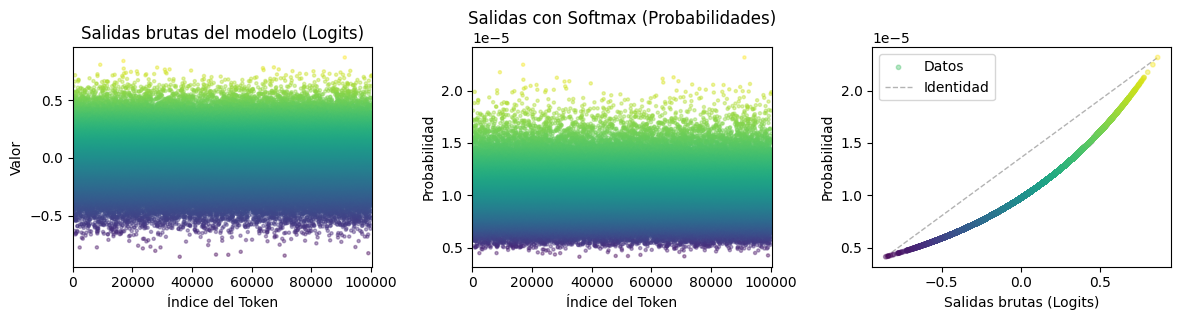

In [13]:
# Visualizar la salida tras aplicar Softmax
final = out[-1, :].detach()
softmaxFinal = torch.exp(final) / torch.exp(final).sum()


# Crear la figura para graficar
_, axs = plt.subplots(1, 3, figsize=(12, 3.3))

# Mostrar los logits brutos (coloreados según su valor)
axs[0].scatter(range(len(final)), final, s=5, marker='o', c=final, alpha=0.4)
axs[0].set(
    title='Salidas brutas del modelo (Logits)',
    xlabel='Índice del Token',
    ylabel='Valor',
    xlim=[0, len(final)],
)

# Logits transformados con Softmax (probabilidades normalizadas)
axs[1].scatter(
    range(len(final)), softmaxFinal, s=5, marker='o', c=final, alpha=0.4
)
axs[1].set(
    title='Salidas con Softmax (Probabilidades)',
    xlabel='Índice del Token',
    ylabel='Probabilidad',
    xlim=[0, len(final)],
)

# Relación entre logits y probabilidades resultantes
axs[2].scatter(
    final, softmaxFinal, s=10, marker='o', c=final, alpha=0.4, label='Datos'
)
axs[2].plot(
    [torch.min(final), torch.max(final)],
    [torch.min(softmaxFinal), torch.max(softmaxFinal)],
    '--',
    color=[0.7, 0.7, 0.7],
    linewidth=1,
    label='Identidad',
    zorder=-10,
)
axs[2].set(xlabel='Salidas brutas (Logits)', ylabel='Probabilidad')
axs[2].legend()

plt.tight_layout()
plt.show()

Observa cómo, al aplicar la función Softmax, los valores pequeños y negativos (como en el tercer token) se suprimen, mientras que los valores relativamente grandes se amplifican.Esto significa que a los tokens que el modelo prefiere —es decir, aquellos con logits más altos— se les asigna una probabilidad significativamente mayor. Por el contrario, los tokens con logits bajos o negativos reducen su probabilidad a valores prácticamente nulos.Puntos clave resumidos:Logits altos: Se potencian y reciben las probabilidades más elevadas.Logits pequeños o negativos: Se comprimen cerca de $0$, suprimiendo los tokens menos probables.

## 7. Pruebas de Generación Autoregresiva de Texto

In [14]:
# Agrega una dimensión extra al inicio de 'X' para simular un batch de tamaño 1 (pasa de [8] a [1, 8])
# y genera 10 nuevos tokens autoregresivamente usando el método 'generate'.
generated_tokens = model.generate(X.unsqueeze(dim=0), 10)

# Toma la primera secuencia del batch generated_tokens[0], la convierte de tensor a una lista de Python
# con .tolist(), y el tokenizador la traduce de IDs numéricos de vuelta a texto legible.
tokenizer.decode(generated_tokens[0].tolist())

' see me in that rayless obscurity deletedycopg              odash Kimberquéikip:description Assuranceiciary'

In [15]:
# Repetir múltiples veces a partir del mismo punto de partida
for i in range(5):

  # Nuevos tokens
  tokz = model.generate(X.unsqueeze(dim=0), 10)
  tokz = tokz[0].tolist()

  # Imprimir la secuencia generada (nuestro "poema" ;))
  print(f'\n\n--- Ejecución {i+1} ---')
  print(tokenizer.decode(tokz))



--- Ejecución 1 ---
 see me in that rayless obscurityprot paramount Client Scholars ~(。“_append=\" finedcalling


--- Ejecución 2 ---
 see me in that rayless obscurity CertselectAll glBegin closevaluatetextbox processo_RG verv Inputs


--- Ejecución 3 ---
 see me in that rayless obscurity climate deferredcomput consolidated_categoria orderBy资源 interrupts navig_INF


--- Ejecución 4 ---
 see me in that rayless obscurity Leaving WhilstGING.days833 THINK predicate_pkt intros Nations


--- Ejecución 5 ---
 see me in that rayless obscurity courage compressor evolves.easing macht ingredientcompilerInactive_mentionsPACKAGE


## Explicacion Final

### **Generación Múltiple desde el Mismo Prompt**

```python
# Repetir múltiples veces desde el mismo punto de partida
for i in range(5):

  # Generar 10 tokens nuevos
  tokz = model.generate(X.unsqueeze(dim=0), 10)
  tokz = tokz[0].tolist()

  # Imprimir nuestro "poema" ;)
  print(f'\n\n--- Run {i+1} ---')
  print(tokenizer.decode(tokz))

```

---

### **Explicación del Código Paso a Paso**

#### **1. El bucle `for i in range(5):**`

Ejecuta el proceso de generación **5 veces seguidas** utilizando exactamente el mismo contexto inicial (`X`).

---

#### **2. `tokz = model.generate(X.unsqueeze(dim=0), 10)**`

* **`X.unsqueeze(dim=0)`**: Añade la dimensión de lote necesaria `[1, 8]`.
* **Generación de 10 tokens**: Llama al método `generate` para producir 10 tokens adicionales uno a uno de forma autoregresiva.
* **Forma resultante**: `[1, 18]` (los 8 tokens originales del prompt + 10 tokens nuevos).

---

#### **3. `tokz = tokz[0].tolist()**`

* **`tokz[0]`**: Selecciona la primera (y única) secuencia dentro del batch de tamaño 1, reduciendo la dimensión a `[18]`.
* **`.tolist()`**: Transforma el tensor de PyTorch a una lista estándar de Python (`[104, 23, 895, ...]`) necesaria para que el tokenizador pueda procesarla.

---

#### **4. `tokenizer.decode(tokz)**`

Convierte la lista de IDs de tokens de vuelta a texto legible. Imprime la secuencia completa: los 8 tokens de entrada más los 10 tokens generados.

---

### **Puntos Clave de esta Prueba**

1. **Variabilidad por Muestreo Probabilístico:**
Dado que `generate` utiliza `torch.multinomial` en lugar de una búsqueda codiciosa (*greedy search*), **cada una de las 5 ejecuciones generará un texto diferente**, a pesar de partir exactamente de los mismos 8 tokens de origen.
2. **Texto Aleatorio ("Poema"):**
Como el modelo **aún no ha sido entrenado** y sus pesos son aleatorios, el texto resultante será una secuencia incoherente de caracteres o palabras sueltas. La prueba sirve para verificar que la **mecánica del bucle autoregresivo y el flujo de tensores funcionan correctamente**.

In [16]:
# Múltiples lotes (batches)

In [17]:
# Instanciamos el DataLoader para procesar datos en lotes paralelos
dataloader = DataLoader(
    token_dataset,
    batch_size=batch_size,
    shuffle=True,
    drop_last=True
)

# Inspeccionamos los índices y dimensiones del primer batch
X, y = next(iter(dataloader))
print(f'Entradas ({batch_size} batches x {seq_len} tokens):')
print(X)

Entradas (5 batches x 8 tokens):
tensor([[  198, 27297,   323,  1139,  2500,   323,  2103,  8294],
        [  382,  2118, 10596,  1618,  2476,  1071,   279, 13235],
        [33243,   304,   279,   198,  1816,  8845,    13,  2684],
        [  578, 40907,   198, 83798, 15187, 61014,   709,   323],
        [  198,   300, 53121,   311,   757,   430,   279, 53722]])


In [18]:
# Obtener las salidas del modelo (logits)
out = model(X)
print(out.shape) # [batch, tokens, tamaño_vocabulario]
print('\n', out)

torch.Size([5, 8, 100277])

 tensor([[[ 0.2775,  1.0448,  0.9170,  ...,  0.7700,  0.1811,  0.2980],
         [ 0.1502, -0.0990, -0.1735,  ...,  0.1265,  0.3511, -0.3476],
         [ 0.7542, -0.0200, -0.2968,  ..., -0.1591,  0.2979, -0.1218],
         ...,
         [ 0.7542, -0.0200, -0.2968,  ..., -0.1591,  0.2979, -0.1218],
         [ 0.1026,  0.9460, -0.1825,  ..., -0.4877,  0.0643,  0.0869],
         [ 0.5191, -0.4218,  1.0149,  ..., -0.0079,  0.5522,  0.0769]],

        [[ 0.4710,  0.5906,  0.5194,  ...,  0.3456, -0.4487,  0.0598],
         [-0.1638, -0.5907, -0.0714,  ..., -0.0480,  0.3082, -0.2153],
         [ 0.1410,  0.6937, -0.0288,  ..., -0.2955, -0.0545,  0.2340],
         ...,
         [ 0.0475, -0.0730,  0.6096,  ..., -0.4361,  0.1439,  0.1113],
         [ 0.3450,  0.1131, -0.0014,  ...,  0.3134, -0.1158,  0.2025],
         [-0.2707, -0.0870,  0.3666,  ..., -0.3579, -0.0300,  0.1427]],

        [[ 0.5822,  0.1710,  0.4421,  ...,  0.1122,  0.0042, -0.3269],
         [ 0.131

In [19]:
# Generar nuevas secuencias a partir del batch
gen_tokens = model.generate(X)
print(gen_tokens.shape) # [batch, (tokens + n_new_tokens)]

torch.Size([5, 38])


In [20]:
# Decodificar e imprimir el texto generado para cada muestra dentro del batch
for batchtok in gen_tokens:
  print('\n--- SIGUIENTE EJEMPLO: ---\n')
  print(tokenizer.decode(batchtok.tolist()))


--- SIGUIENTE EJEMPLO: ---


gallery and into another and still larger Andainality.googleapis Molbam]( paciente Some Kendall<'│атегорPyObject_Xcam/>
	ip.MouseEventобыти suspected imagem код wildfire(Bytes glaciers_BASICEncode tripodccd'))




--- SIGUIENTE EJEMPLO: ---

.

“Look here,” said the Medical stor_socketasion unnatural阳 Enumerator kennenlernen`=FontSize manosTreeNodeotech;heightCouncil ret rogue jasmine.micro(Defaultarendbaar qualitézeniaStateChangedrence polarity Eg-it dau

--- SIGUIENTE EJEMPLO: ---

 incomplete in the
workshop. There contentious persistence.OrdinalIgnoreCaseGetsPrimRecter	ROM []* asia_mgr:async stealth]')
quot Als!!!!!!!! award manifest gist Chess claroutationsbelieemplate ArrayAdapter.GroupLayout Flight "/";
 constitution

--- SIGUIENTE EJEMPLO: ---

 The bronze
panels suddenly slid up and BrowserAnimationsModuleinand gladlyandWheregroupidWeightsanioibur seemed pci amended Intersection tiledKelly Exodus recl052grossball_dtype earthqu RIDOuterenheim conf

Tu intuición sobre cómo debe funcionar un modelo de lenguaje es **impecable**, pero hay un **matiz fundamental** entre el modelo básico que acabamos de escribir y el modelo hacia el que estamos evolucionando (un Transformer):

---

### **1. En un Transformer real (el objetivo final)**

Es **exactamente como acabas de describir**:

* Mediante el mecanismo de **Autoatención (Self-Attention)**, cada vector de embedding "mira hacia atrás", intercambia información con los tokens anteriores y actualiza su propio contenido.
* Al llegar a la última capa del modelo, el vector de la última posición ha "absorbido" la representación acumulada de toda la secuencia.
* Por esta razón, para predecir el siguiente token basta con tomar únicamente la última posición (`x[:, -1, :]`), pues contiene todo el contexto comprimido.

---

### **2. En nuestro modelo actual (el modelo simple / *Toy Model*)**

En el código que escribimos hace un momento, las capas eran únicamente:


$$\text{Embedding} \longrightarrow \text{GELU} \longrightarrow \text{Linear}$$

* Dado que no hay capas de atención ni conexiones entre posiciones, las transformaciones se aplican a cada token de forma **totalmente independiente** (*pointwise*).
* En este modelo elemental, el token en la posición 7 **todavía no sabe** qué palabras estaban en las posiciones 0 a 6.

---

### **Por qué este contraste es tan importante**

Haber identificado esta propiedad revela la **limitación central** de nuestro modelo actual: sin un mecanismo que mezcle la información entre tokens a lo largo del tiempo, el modelo no puede aprender relaciones de contexto.

Este es precisamente el motivo por el cual la arquitectura debe volverse más compleja: el siguiente paso natural es introducir **Self-Attention** para que los vectores de embedding finalmente puedan intercambiar información y cumplir exactamente con tu conclusión.

## CONCLUSION

En lo siguiente vamos a desempaquetar todo esto para comprender un poco mas el modelo. Añadir mas mecanismos, Ajustes, regularizaciones, normalizaciones etc

Así que vamos a concluir diciendo que, cuando se tiene una secuencia de tokens que pasan a través del modelo, cada token no es el mismo vector de embeddings con el que empezamos. En su lugar, cada vector de embeddings se modifica para contener toda la información sobre los tokens anteriores.

Por lo tanto, utilizar solo el último token para predecir el nuevo token significa que estamos utilizando todos los tokens: nos centramos en el que contiene más información contextual.